# THYROID CANCER PREDICTION MODEL

#DATA HANDLING

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv('thyroid_cancer_risk_data.csv')
df

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212686,212687,58,Female,India,Asian,No,No,No,No,Yes,No,2.00,0.64,11.92,1.48,Low,Benign
212687,212688,89,Male,Japan,Middle Eastern,No,No,No,No,Yes,No,9.77,3.25,7.30,4.46,Medium,Benign
212688,212689,72,Female,Nigeria,Hispanic,No,No,No,No,No,Yes,7.72,2.44,8.71,2.36,Medium,Benign
212689,212690,85,Female,Brazil,Middle Eastern,No,No,No,No,No,Yes,5.62,2.53,9.62,1.54,Medium,Benign


In [16]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country', 'Ethnicity', 'Family_History',
       'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity',
       'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size',
       'Thyroid_Cancer_Risk', 'Diagnosis'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212691 entries, 0 to 212690
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Patient_ID           212691 non-null  int64  
 1   Age                  212691 non-null  int64  
 2   Gender               212691 non-null  object 
 3   Country              212691 non-null  object 
 4   Ethnicity            212691 non-null  object 
 5   Family_History       212691 non-null  object 
 6   Radiation_Exposure   212691 non-null  object 
 7   Iodine_Deficiency    212691 non-null  object 
 8   Smoking              212691 non-null  object 
 9   Obesity              212691 non-null  object 
 10  Diabetes             212691 non-null  object 
 11  TSH_Level            212691 non-null  float64
 12  T3_Level             212691 non-null  float64
 13  T4_Level             212691 non-null  float64
 14  Nodule_Size          212691 non-null  float64
 15  Thyroid_Cancer_Ri

In [18]:
from sklearn.preprocessing import LabelEncoder
family_history_enco = LabelEncoder()
radiation_expo_enco = LabelEncoder()
Iodine_defi_enco = LabelEncoder()
Smoking_enco = LabelEncoder()
Diabetes_enco = LabelEncoder()
obesity_enco = LabelEncoder()
Thyroid_cancer_risk_enco = LabelEncoder()


In [ ]:
df['Family_History'] = family_history_enco.fit_transform(df['Family_History'])
df['Radiation_Exposure'] = radiation_expo_enco.fit_transform(df['Radiation_Exposure'])
df['Iodine_Deficiency'] = Iodine_defi_enco.fit_transform(df['Iodine_Deficiency'])
df['Smoking'] = Smoking_enco.fit_transform(df['Smoking'])
df['Obesity'] = obesity_enco.fit_transform(df['Obesity'])
df['Diabetes'] = Diabetes_enco.fit_transform(df['Diabetes'])

In [20]:
df

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,0,1,0,0,0,0,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,0,1,0,0,0,0,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,0,0,0,0,0,0,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,0,0,0,0,0,0,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,1,1,0,0,0,0,9.10,2.11,10.71,2.11,High,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212686,212687,58,Female,India,Asian,0,0,0,0,1,0,2.00,0.64,11.92,1.48,Low,Benign
212687,212688,89,Male,Japan,Middle Eastern,0,0,0,0,1,0,9.77,3.25,7.30,4.46,Medium,Benign
212688,212689,72,Female,Nigeria,Hispanic,0,0,0,0,0,1,7.72,2.44,8.71,2.36,Medium,Benign
212689,212690,85,Female,Brazil,Middle Eastern,0,0,0,0,0,1,5.62,2.53,9.62,1.54,Medium,Benign


#CLUSTERING

In [21]:
from sklearn.cluster import KMeans
cluster = KMeans(n_clusters=3,random_state=42,n_init=10)
features = [
    'Family_History',
    'Radiation_Exposure',
    'Iodine_Deficiency',
    'Smoking',
    'Obesity',
    'Diabetes',
    'TSH_Level',
    'T3_Level',
    'T4_Level',
    'Nodule_Size'
]
df['risk_cluster'] = cluster.fit_predict(df[features])
df['risk_cluster']

0         0
1         1
2         0
3         1
4         0
         ..
212686    1
212687    0
212688    0
212689    0
212690    1
Name: risk_cluster, Length: 212691, dtype: int32

In [22]:
df['risk_cluster'].unique()

array([0, 1, 2], dtype=int32)

In [23]:
df[['Thyroid_Cancer_Risk','risk_cluster']].drop_duplicates()

,Thyroid_Cancer_Risk,risk_cluster
0,Low,0
1,Low,1
3,Medium,1
4,High,0
5,Medium,2
6,High,1
7,Medium,0
9,Low,2
71,High,2


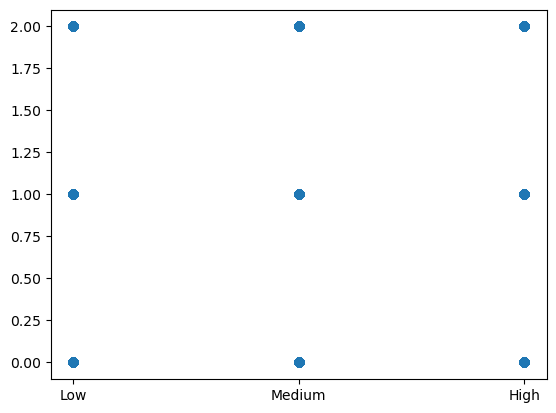

In [24]:
plt.figure()
plt.scatter(df['Thyroid_Cancer_Risk'],df['risk_cluster'])

In [25]:
df['Thyroid_Cancer_Risk'] = Thyroid_cancer_risk_enco.fit_transform(df['Thyroid_Cancer_Risk'])


# CLUSTERING FAILS HERE 

# LETS DO LOGISTIC REGRESSION THEN

#MODEL FITTING

In [ ]:
gender_enco = LabelEncoder()
df['Gender_encoded'] = gender_enco.fit_transform(df['Gender'])
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
age = float(input('enter the age of patient: '))
gender = int(input('enter gender of the patient: '))
family_history = int(input('does your family history has any patient of throid cancer: '))
radiation_exposure = int(input('radiation exposure: '))
iodine_deficiency = int(input('does patient has iodine deficiency: '))
smoking = int(input('does patient do smoking: '))
obesity = int(input('does patient suffers obesity: '))
diabetes = int(input('does patient has diabetes: '))
tsh_level = float(input('enter TSH level of patient: '))
t3_level = float(input('enter T3 level of patient: '))
t4_level = float(input('enter T4 level of patient: '))
nodule_size = float(input('enter nodule size: '))
fit_features = [
    'Age',
    'Gender_encoded'
    'Family_History',
    'Radiation_Exposure',
    'Iodine_Deficiency',
    'Smoking',
    'Obesity',
    'Diabetes',
    'TSH_Level',
    'T3_Level',
    'T4_Level',
    'Nodule_Size'
]
input_features = [
    age,
    gender,
    family_history,
    radiation_exposure,
    iodine_deficiency,
    smoking,
    obesity,
    diabetes,
    tsh_level,
    t3_level,
    t4_level,
    nodule_size
]
X = df[fit_features]
y = df['Thyroid_Cancer_Risk']
model.fit(X,y)
answer = model.predict([[input_features]])
answer = Thyroid_cancer_risk_enco.inverse_transform(answer)[0]
